## Hyperparameters to tune

- Tune hidden layer sizes using candidate tuples, ie. (128, 128), (64, 64, 64) etc.
- Dropout (constant across layers)
- Learning rate
- Batch size

Using 320 shots to run as a good middle ground
params chosen with fidelity loss

Don't tune epochs
Instead measure the loss and show the converging loss curve across the epochs in the report and as justification for how many epochs to use
(Use a large max epoch and stop early if reaches a constraint)

For each hyperparameter, justify through literature why it's valid but for the specific value taken, being chosen empirically through optimisation is defensible.

In [3]:
import numpy as np
import QST_core_processes as qst
import pickle
import os
data_train = np.load("data/hyperparam_tuning_set_train.npz", allow_pickle=True)
data_val = np.load("data/hyperparam_tuning_set_test.npz", allow_pickle=True)

In [4]:
# Lists stored for future analysis/ graphing of parameter space
hidden_layers = []
dropouts = []
learning_rates = []
batch_sizes = []

final_losses = []
best_losses = []

In [11]:
hidden_size_candidates = [
    (128, 128),            # 2 layers
    (256, 256),            # 2 layers wide
    (256, 128, 64),        # 3 layers tapered
    (256, 256, 128),       # 3 layers wide
    (256, 256, 128, 64),   # 4 layers
]

dropout_candidates = [0.0, 0.1, 0.2]
learning_rate_candidates = [1e-3, 5e-4, 1e-4]
batch_size_candidates = [64, 128, 256]

In [ ]:
results = []
path = "hyperparam_results.pkl"
run = 1
runs = len(hidden_size_candidates) * len(dropout_candidates) * len(learning_rate_candidates) * len(batch_size_candidates)

if os.path.exists(path):
    with open(path, "rb") as f:
        results = pickle.load(f)

for hidden_size in hidden_size_candidates:
    for dropout in dropout_candidates:
        for learning_rate in learning_rate_candidates:
            for batch_size in batch_size_candidates:
                print(f"Run {run} out of {runs}: Training with hidden_size={hidden_size}, dropout={dropout}, learning_rate={learning_rate}, batch_size={batch_size}")
                run += 1
                model = qst.NN_Builder(
                    n_qubits=2,
                    model_type="mlp",
                    loss_type="fidelity",
                    target="tau",
                    hidden_sizes=hidden_size,
                    dropout=dropout,
                    lr=learning_rate,
                    batch_size=batch_size,
                    epochs=100
                )

                history, _ = model.fit_and_predict(data_train, data_val)
                final_loss = history["loss"][-1]
                best_loss = min(history["loss"])

                result = {
                    "hidden_size": hidden_size,
                    "dropout": dropout,
                    "learning_rate": learning_rate,
                    "batch_size": batch_size,
                    "final_loss": final_loss,
                    "best_loss": best_loss
                }
                results.append(result)

                # with open(path, "wb") as f:
                #     pickle.dump(results, f)
                ### Commented to avoid overwriting

Run 1 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.001, batch_size=64
Run 2 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.001, batch_size=128
Run 3 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.001, batch_size=256
Run 4 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0005, batch_size=64
Run 5 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0005, batch_size=128
Run 6 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0005, batch_size=256
Run 7 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0001, batch_size=64
Run 8 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0001, batch_size=128
Run 9 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0001, batch_size=256
Run 10 out of 135: Training with hidden_size=(128, 1

## For final best chosen model, record again and use that epoch loss curve to show not under or overfitting

**Mention in report that doing a broad parameter search first, then narrowing search around promising param space, common method**

In [34]:
import pandas as pd

with open(path, "rb") as f:
    results = pickle.load(f)

df = pd.DataFrame(results)
df = df.sort_values(by="final_loss")

In [ ]:
# Extract unconverged runs and redo with 200 epochs

config_cols = ["hidden_size", "dropout", "learning_rate", "batch_size"]

rerun_df = df[df["final_loss"] == df["best_loss"]][config_cols].drop_duplicates()

configs_to_rerun = list(rerun_df.itertuples(index=False, name=None))

run = 1
for hidden_size, dropout, learning_rate, batch_size in configs_to_rerun:
    print(f"Rerun {run} out of {len(configs_to_rerun)}: Rerunning with hidden_size={hidden_size}, dropout={dropout}, learning_rate={learning_rate}, batch_size={batch_size}")
    run += 1
    model = qst.NN_Builder(
        n_qubits=2,
        model_type="mlp",
        loss_type="fidelity",
        target="tau",
        hidden_sizes=hidden_size,
        dropout=dropout,
        lr=learning_rate,
        batch_size=batch_size,
        epochs=200
    )

    history, _ = model.fit_and_predict(data_train, data_val)
    final_loss = history["loss"][-1]
    best_loss = min(history["loss"])

    result = {
        "hidden_size": hidden_size,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "final_loss": final_loss,
        "best_loss": best_loss
    }
    results.append(result)

    # with open(path, "wb") as f:
    #     pickle.dump(results, f)

Rerun 1 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.2, learning_rate=0.0005, batch_size=64
Rerun 2 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.1, learning_rate=0.0005, batch_size=128
Rerun 3 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.1, learning_rate=0.0005, batch_size=256
Rerun 4 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.2, learning_rate=0.0005, batch_size=256
Rerun 5 out of 46: Rerunning with hidden_size=(256, 256, 128), dropout=0.2, learning_rate=0.0005, batch_size=256
Rerun 6 out of 46: Rerunning with hidden_size=(256, 256, 128), dropout=0.1, learning_rate=0.0001, batch_size=64
Rerun 7 out of 46: Rerunning with hidden_size=(256, 128, 64), dropout=0.1, learning_rate=0.001, batch_size=128
Rerun 8 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.2, learning_rate=0.0001, batch_size=64
Rerun 9 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.1, learning_rate=0.0001, batch_size=64
Rerun 10 out of 46:

## Go from here onwards in order to not rewrite results!!! Rerunning ones that didnt converge with more epochs for fairer testing, and removing initial
#### Once this is done - we will ascertain best params and run on a more localised set of candidates

In [64]:
config_cols = ["hidden_size", "dropout", "learning_rate", "batch_size"]

with open('hyperparam_results.pkl', "rb") as f:
    results = pickle.load(f)

df = pd.DataFrame(results)
df = df.sort_index().drop_duplicates(subset=config_cols, keep="last").reset_index(drop=True)

In [65]:
df[df["final_loss"] == df['best_loss']].shape

(5, 6)

In [66]:
df.sort_values(by="best_loss").head(10)

,hidden_size,dropout,learning_rate,batch_size,final_loss,best_loss
94,"(256, 256, 128)",0.1,0.0001,64,0.059360,0.058878
62,"(256, 256, 128)",0.1,0.0005,64,0.060240,0.059088
59,"(256, 256, 128)",0.1,0.0010,64,0.059750,0.059154
63,"(256, 256, 128)",0.1,0.0005,128,0.060103,0.059246
93,"(256, 256, 128)",0.2,0.0005,256,0.059912,0.059497
89,"(256, 256)",0.2,0.0005,64,0.060100,0.059505
92,"(256, 256)",0.2,0.0005,256,0.061274,0.059551
60,"(256, 256, 128)",0.1,0.0010,128,0.061285,0.059571
61,"(256, 256, 128)",0.1,0.0010,256,0.059925,0.059879
99,"(256, 256, 128)",0.1,0.0001,128,0.060419,0.060179


In [67]:
df.groupby('learning_rate')['best_loss'].mean()

learning_rate
0.0001    0.079971
0.0005    0.069857
0.0010    0.067057
Name: best_loss, dtype: float64

In [68]:
hidden_size_local = [
    (128, 192, 128),
    (128, 256, 128),
    (192, 256, 128),
    (256, 256, 128),
    (256, 192, 128),
    (256, 256, 256)
]
dropouts_local = [0.05, 0.075, 0.1, 0.125, 0.15]
batch_size_local = [48, 64, 80]

Learning rate has minimal effect, and just balances with epochs. Defnesible to use 5e-4 lr and 150 epochs to find less expensive middle ground
"Preliminary experiments showed that a learning rate of 10e-4 required substantially more epochs to converge, with limited improvement in validation loss, while 10e-3 converged more rapidly but was more aggressive. A value of 5e-4 with 150 epochs was therefore selected as a compromise between convergence quality and computational cost."
Show lr balancing with epochs to not under or overfit
Now searching in 3 hidden layers, around 0.1 dropout, and around 64 batch size

In [ ]:
results = []
path_local = "hyperparam_results_local.pkl"
run = 1
runs = len(hidden_size_local) * len(dropouts_local) * len(batch_size_local)

if os.path.exists(path_local):
    with open(path_local, "rb") as f:
        results = pickle.load(f)

for hidden_size in hidden_size_local:
    for dropout in dropouts_local:
        for batch_size in batch_size_local:
            print(f"Run {run} out of {runs}: Training with hidden_size={hidden_size}, dropout={dropout}, learning_rate={learning_rate}, batch_size={batch_size}")
            run += 1
            model = qst.NN_Builder(
                n_qubits=2,
                model_type="mlp",
                loss_type="fidelity",
                target="tau",
                hidden_sizes=hidden_size,
                dropout=dropout,
                lr=5e-4,
                batch_size=batch_size,
                epochs=150
            )

            history, _ = model.fit_and_predict(data_train, data_val)
            final_loss = history["loss"][-1]
            best_loss = min(history["loss"])

            result = {
                "hidden_size": hidden_size,
                "dropout": dropout,
                "learning_rate": 5e-4,
                "batch_size": batch_size,
                "final_loss": final_loss,
                "best_loss": best_loss
            }
            results.append(result)

            # with open(path_local, "wb") as f:
            #     pickle.dump(results, f)
            ## Commented to avoid overwriting

Run 1 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.05, learning_rate=0.0001, batch_size=48
Run 2 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.05, learning_rate=0.0001, batch_size=64
Run 3 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.05, learning_rate=0.0001, batch_size=80
Run 4 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.075, learning_rate=0.0001, batch_size=48
Run 5 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.075, learning_rate=0.0001, batch_size=64
Run 6 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.075, learning_rate=0.0001, batch_size=80
Run 7 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.1, learning_rate=0.0001, batch_size=48
Run 8 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.1, learning_rate=0.0001, batch_size=64
Run 9 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.1, learning_rate=0.0001, batch_size=80
Run 10 out

If outputs give (256,256,256) as best layer structure, then can retest on more nodes.

## All data finally collected now.

In [3]:
import pickle
import pandas as pd

config_cols = ["hidden_size", "dropout", "learning_rate", "batch_size"]

with open('hyperparam_results.pkl', "rb") as f:
    results = pickle.load(f)

df1 = pd.DataFrame(results)

with open('hyperparam_results_local.pkl', "rb") as f:
    results_local = pickle.load(f)

df2 = pd.DataFrame(results_local)

# df = pd.concat([df1, df2], ignore_index=True).drop_duplicates(subset=config_cols, keep="last").sort_values(by="best_loss").reset_index(drop=True)
df = df2.sort_values(by="best_loss").reset_index(drop=True)
df.head(10)

,hidden_size,dropout,learning_rate,batch_size,final_loss,best_loss
0,"(256, 256, 256)",0.150,0.0005,80,0.056209,0.056207
1,"(256, 256, 256)",0.125,0.0005,80,0.057448,0.056295
2,"(256, 256, 256)",0.125,0.0005,48,0.057394,0.056552
3,"(256, 256, 256)",0.150,0.0005,64,0.057324,0.056750
4,"(256, 256, 256)",0.150,0.0005,48,0.058399,0.057048
5,"(256, 256, 256)",0.100,0.0005,64,0.058098,0.057095
6,"(256, 256, 256)",0.100,0.0005,48,0.058903,0.057194
7,"(256, 256, 256)",0.100,0.0005,80,0.057766,0.057194
8,"(256, 256, 256)",0.125,0.0005,64,0.057265,0.057265
9,"(256, 256, 256)",0.075,0.0005,48,0.058449,0.057365


In [5]:
df.groupby('hidden_size')['best_loss'].median()

hidden_size
(128, 192, 128)    0.061200
(128, 256, 128)    0.061054
(192, 256, 128)    0.059463
(256, 192, 128)    0.058771
(256, 256, 128)    0.058592
(256, 256, 256)    0.057194
Name: best_loss, dtype: float64

In [6]:
df.groupby('batch_size')['best_loss'].median()

batch_size
48    0.059291
64    0.059316
80    0.059269
Name: best_loss, dtype: float64

In [7]:
df.groupby('dropout')['best_loss'].median()

dropout
0.050    0.059534
0.075    0.058880
0.100    0.059129
0.125    0.059130
0.150    0.059190
Name: best_loss, dtype: float64

## Results - RUN T TESTS TO VERIFY NO SIG DIFFERENCE
#### Can say (256, 256, 256), dropout of 8%, batch size of 64 are significant as the best parameters

Main text - state final hyperparams in report, with explanation of two stage prcoess. Have a small table of the best configs to show how the choice emerged. Include an explanation of how epoch curve used with learning rate to avoid under and overfitting. 

Appendix - full search results and exploration of parameters during search

In [5]:
import QST_core_processes as qst
import numpy as np
import matplotlib.pyplot as plt

final_model = qst.NN_Builder(
    n_qubits=2,
    model_type="mlp",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.08,
    lr=5e-4,
    batch_size=64,
    epochs=200
)

epoch_history, _, _ = final_model.fit_and_predict(data_train, data_val)

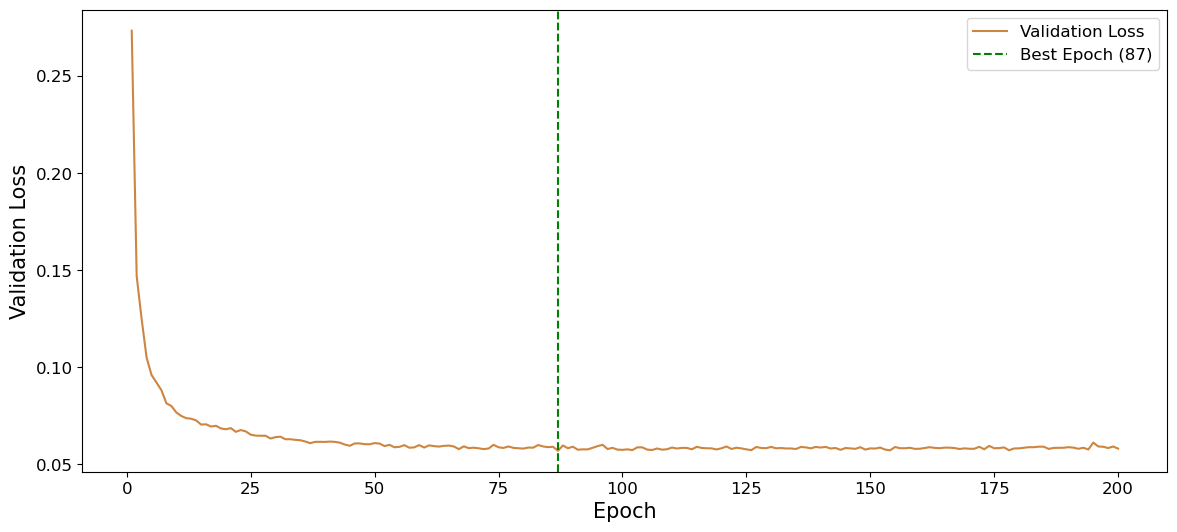

In [10]:
loss_history = epoch_history["loss"]
epochs = range(1, len(loss_history) + 1)
best_epoch = np.argmin(loss_history) + 1

plt.figure(figsize=(14, 6))
plt.plot(epochs, loss_history, label="Validation Loss", color='peru')

plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch ({best_epoch})", color='green')

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Validation Loss", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.savefig("final_model_training_curve.png", dpi=600)
plt.show()

When using learning rate of 5e-4, choosing to use 100 epochs, as close enough to 106 that will make a negligible difference. And varies between datasets anyway. Cleaner than 106 and shown to not be under or overfitting